In [ ]:
# Remove old files if any
!rm -rf train2017 val2017 annotations train2017.zip val2017.zip annotations_trainval2017.zip

# Download COCO 2017 dataset
!wget http://images.cocodataset.org/zips/train2017.zip
!wget http://images.cocodataset.org/zips/val2017.zip
!wget http://images.cocodataset.org/annotations/annotations_trainval2017.zip

# Unzip
!unzip -q train2017.zip
!unzip -q val2017.zip
!unzip -q annotations_trainval2017.zip


--2025-11-21 13:31:20--  http://images.cocodataset.org/zips/train2017.zip
Resolving images.cocodataset.org (images.cocodataset.org)... 16.15.201.202, 54.231.170.217, 52.216.86.131, ...
Connecting to images.cocodataset.org (images.cocodataset.org)|16.15.201.202|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 19336861798 (18G) [application/zip]
Saving to: ‘train2017.zip’

train2017.zip       100%[===================>]  18.01G  54.3MB/s    in 6m 32s  

2025-11-21 13:37:52 (47.0 MB/s) - ‘train2017.zip’ saved [19336861798/19336861798]

--2025-11-21 13:37:52--  http://images.cocodataset.org/zips/val2017.zip
Resolving images.cocodataset.org (images.cocodataset.org)... 52.217.125.161, 16.15.187.53, 3.5.25.91, ...
Connecting to images.cocodataset.org (images.cocodataset.org)|52.217.125.161|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 815585330 (778M) [application/zip]
Saving to: ‘val2017.zip’

val2017.zip         100%[===================>] 77

In [ ]:
from pycocotools.coco import COCO
import os
import random
import numpy as np
from PIL import Image
from tqdm import tqdm

# Annotation file
annFile = "./annotations/instances_train2017.json"
coco = COCO(annFile)

# Sample 4000 images for quicker training
img_ids = coco.getImgIds()
selected_ids = random.sample(img_ids, 4000)

# Create folders for processed dataset
os.makedirs("dataset/images", exist_ok=True)
os.makedirs("dataset/masks", exist_ok=True)

# Generate images and binary masks
for img_id in tqdm(selected_ids, desc="Generating dataset"):
    info = coco.loadImgs(img_id)[0]
    img_path = f"./train2017/{info['file_name']}"
    image = np.array(Image.open(img_path).convert("RGB"))

    ann_ids = coco.getAnnIds(imgIds=img_id)
    anns = coco.loadAnns(ann_ids)

    mask = np.zeros((info['height'], info['width']), dtype=np.uint8)
    for ann in anns:
        mask = np.maximum(mask, coco.annToMask(ann))

    # Save image and mask
    Image.fromarray(image).save(f"dataset/images/{info['file_name']}")
    Image.fromarray(mask * 255).save(f"dataset/masks/{info['file_name'].replace('.jpg','.png')}")


loading annotations into memory...
Done (t=13.75s)
creating index...
index created!


Generating dataset: 100%|██████████| 4000/4000 [01:04<00:00, 62.23it/s]


In [ ]:
files = sorted(os.listdir("dataset/images"))
train_files = files[:3200]
val_files   = files[3200:]


In [ ]:
import albumentations as A
from albumentations.pytorch import ToTensorV2

train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.ColorJitter(p=0.3),
    A.Resize(512, 512),
    ToTensorV2(),
])

val_transform = A.Compose([
    A.Resize(512, 512),
    ToTensorV2(),
])


In [ ]:
from torch.utils.data import Dataset
import cv2
import torch

class CocoSegDataset(Dataset):
    def __init__(self, files, transform):
        self.files = files
        self.transform = transform

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        fname = self.files[idx]

        img = cv2.imread(f"dataset/images/{fname}")
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        mask = cv2.imread(f"dataset/masks/{fname.replace('.jpg', '.png')}", cv2.IMREAD_GRAYSCALE)
        mask = (mask > 128).astype("uint8")

        aug = self.transform(image=img, mask=mask)
        img = aug["image"].float() / 255.0
        mask = aug["mask"].unsqueeze(0).float()

        return img, mask


In [ ]:
from torch.utils.data import DataLoader

train_ds = CocoSegDataset(train_files, train_transform)
val_ds   = CocoSegDataset(val_files, val_transform)

train_loader = DataLoader(train_ds, batch_size=8, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_ds, batch_size=8, shuffle=False, num_workers=2)

print("Train samples:", len(train_ds), "| Validation samples:", len(val_ds))


Train samples: 3200 | Validation samples: 800


In [ ]:
!pip install segmentation-models-pytorch==0.3.3 albumentations==1.4.3 --quiet


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.8/58.8 kB 5.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.5/68.5 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 106.7/106.7 kB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.0/137.0 kB 13.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 59.1 MB/s eta 0:00:00


In [ ]:
import segmentation_models_pytorch as smp
import torch
import torch.nn as nn

device = "cuda" if torch.cuda.is_available() else "cpu"


In [ ]:
import segmentation_models_pytorch as smp
import torch
import torch.nn as nn

device = "cuda" if torch.cuda.is_available() else "cpu"

# Load U-Net
model = smp.Unet(
    encoder_name="resnet101",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1,  # still 1 channel output
    activation=None
)

# ------------------ Unfreeze higher layers ------------------
for name, param in model.encoder.named_parameters():
    if "layer3" in name or "layer4" in name:
        param.requires_grad = True
    else:
        param.requires_grad = False

# ------------------ Extra head ------------------
model.extra_head = nn.Sequential(
    nn.Conv2d(1, 64, 3, padding=1),
    nn.ReLU(inplace=True),
    nn.Conv2d(64, 32, 3, padding=1),
    nn.ReLU(inplace=True),
    nn.Conv2d(32, 16, 3, padding=1),
    nn.ReLU(inplace=True),
    nn.Conv2d(16, 1, 1)
)

# Modify forward
old_forward = model.forward
def new_forward(x):
    x = old_forward(x)
    x = model.extra_head(x)
    return x
model.forward = new_forward
model.to(device)


Downloading: "https://download.pytorch.org/models/resnet101-5d3b4d8f.pth" to /root/.cache/torch/hub/checkpoints/resnet101-5d3b4d8f.pth


100%|██████████| 170M/170M [00:00<00:00, 264MB/s]


Unet(
  (encoder): ResNetEncoder(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequential(
      

In [ ]:
import torch.nn.functional as F

def dice_loss(pred, target, smooth=1e-6):
    pred = torch.sigmoid(pred)
    inter = (pred * target).sum(dim=(2,3))
    union = pred.sum(dim=(2,3)) + target.sum(dim=(2,3))
    dice = (2*inter + smooth) / (union + smooth)
    return 1 - dice.mean()

def combined_loss(pred, target):
    bce = F.binary_cross_entropy_with_logits(pred, target)
    d   = dice_loss(pred, target)
    return 0.5*bce + 0.5*d


In [ ]:
optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=2)


In [ ]:
from tqdm import tqdm

num_epochs = 10

for epoch in range(num_epochs):
    model.train()
    train_loss = 0

    for imgs, masks in tqdm(train_loader):
        imgs, masks = imgs.to(device), masks.to(device)

        optimizer.zero_grad()
        preds = model(imgs)

        loss = combined_loss(preds, masks)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    # Validation
    model.eval()
    val_loss = 0
    iou_total = 0
    count = 0

    with torch.no_grad():
        for imgs, masks in val_loader:
            imgs, masks = imgs.to(device), masks.to(device)
            preds = model(imgs)

            val_loss += combined_loss(preds, masks).item()

            pr = (torch.sigmoid(preds) > 0.5).float()
            inter = (pr * masks).sum()
            union = ((pr + masks) > 0).float().sum()
            iou_total += (inter / (union + 1e-6)).item()
            count += 1

    avg_train = train_loss / len(train_loader)
    avg_val = val_loss / len(val_loader)
    avg_iou = iou_total / count

    scheduler.step(avg_val)

    print(f"Epoch {epoch+1}/{num_epochs} | Train={avg_train:.4f} | Val={avg_val:.4f} | IoU={avg_iou:.4f}")


100%|██████████| 400/400 [05:54<00:00,  1.13it/s]


Epoch 1/10 | Train=0.4978 | Val=0.3777 | IoU=0.5969


100%|██████████| 400/400 [06:04<00:00,  1.10it/s]


Epoch 2/10 | Train=0.3886 | Val=0.3298 | IoU=0.6292


100%|██████████| 400/400 [06:05<00:00,  1.09it/s]


...

Epoch 8/10 | Train=0.2931 | Val=0.3231 | IoU=0.6364


100%|██████████| 400/400 [06:05<00:00,  1.09it/s]


Epoch 9/10 | Train=0.2870 | Val=0.3146 | IoU=0.6543


100%|██████████| 400/400 [06:05<00:00,  1.09it/s]


Epoch 10/10 | Train=0.2526 | Val=0.2986 | IoU=0.6588


In [ ]:
import torch
import numpy as np

def final_iou(pred, target, eps=1e-6):
    pred = (torch.sigmoid(pred) > 0.5).float()
    inter = (pred * target).sum(dim=(2,3))
    union = ((pred + target) > 0).float().sum(dim=(2,3))
    return ((inter + eps) / (union + eps)).mean().item()

def final_dice(pred, target, eps=1e-6):
    pred = (torch.sigmoid(pred) > 0.5).float()
    inter = (pred * target).sum(dim=(2,3))
    total = pred.sum(dim=(2,3)) + target.sum(dim=(2,3))
    return ((2*inter + eps) / (total + eps)).mean().item()

def pixel_acc(pred, target):
    pred = (torch.sigmoid(pred) > 0.5).float()
    correct = (pred == target).float().sum()
    total = torch.numel(pred)
    return (correct / total).item()


model.eval()

total_iou = 0
total_dice = 0
total_pixel_acc = 0
count = 0

with torch.no_grad():
    for imgs, masks in val_loader:
        imgs, masks = imgs.to(device), masks.to(device)
        preds = model(imgs)

        total_iou += final_iou(preds, masks)
        total_dice += final_dice(preds, masks)
        total_pixel_acc += pixel_acc(preds, masks)
        count += 1

print("\n================ FINAL VALIDATION ACCURACY ================")
print(f"Mean IoU          : {total_iou / count:.4f}")
print(f"Mean Dice Score   : {total_dice / count:.4f}")
print(f"Pixel Accuracy    : {total_pixel_acc / count:.4f}")
print("============================================================\n")



================ FINAL VALIDATION ACCURACY ================
Mean IoU          : 0.6432
Mean Dice Score   : 0.7467
Pixel Accuracy    : 0.8871



In [ ]:
torch.save(model.state_dict(), "final_unet_resnet101_rgb.pth")
print("✅ Model saved!")


✅ Model saved!


In [ ]:
import cv2
import numpy as np

def clean_mask(mask):
    """mask: numpy binary mask HxW"""
    mask = mask.astype(np.uint8)

    # Remove small blobs
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask, connectivity=8)

    cleaned = np.zeros_like(mask)
    for i in range(1, num_labels):
        area = stats[i, cv2.CC_STAT_AREA]
        if area > 500:
            cleaned[labels == i] = 1

    # Optional: close holes
    kernel = np.ones((5,5), np.uint8)
    cleaned = cv2.morphologyEx(cleaned, cv2.MORPH_CLOSE, kernel)

    return cleaned


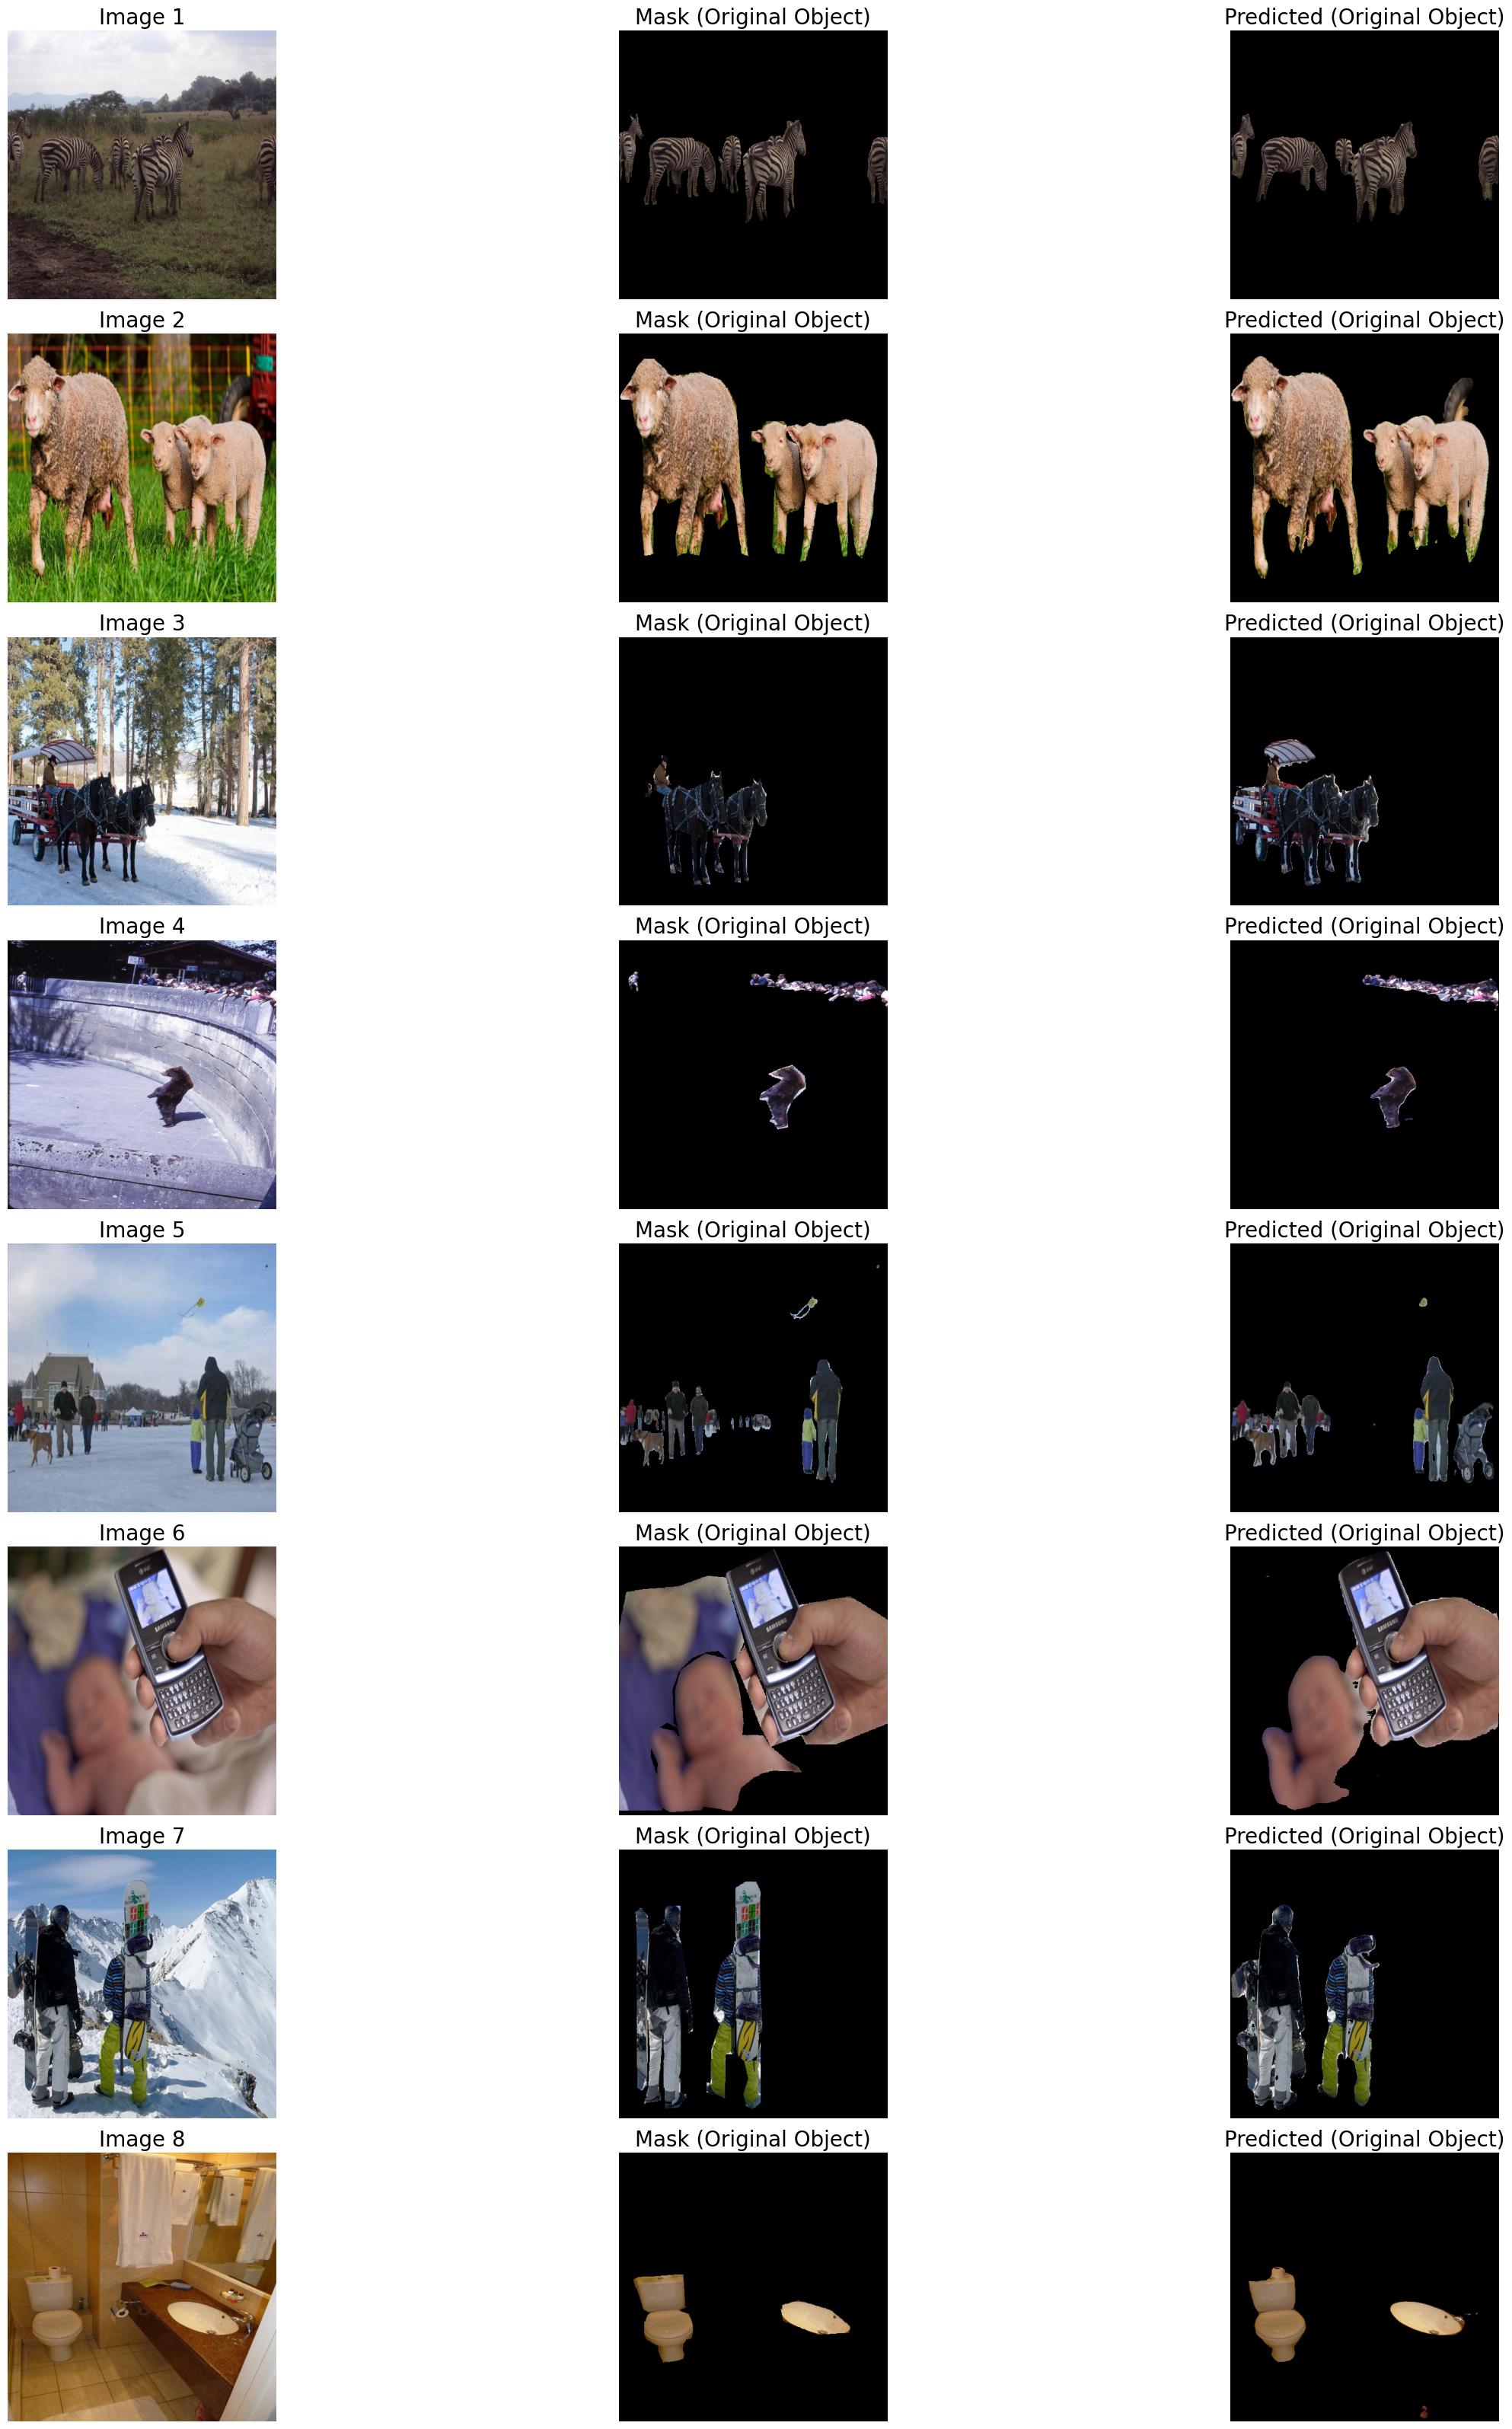

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch

model.eval()
imgs, masks = next(iter(val_loader))
imgs, masks = imgs[:8].to(device), masks[:8].to(device)

preds = model(imgs)
preds = (torch.sigmoid(preds) > 0.5).float().cpu().numpy()
imgs_np = imgs.cpu().numpy()


plt.figure(figsize=(28, 32))


for i in range(8):
    orig_img = np.transpose(imgs_np[i], (1,2,0))

    # Predicted mask
    pred_mask = preds[i][0]
    pred_mask_3c = np.repeat(pred_mask[:,:,None], 3, axis=2)
    masked_pred_img = orig_img * pred_mask_3c

    # Ground truth mask
    gt_mask = masks[i][0].cpu().numpy()
    gt_mask_3c = np.repeat(gt_mask[:,:,None], 3, axis=2)
    masked_gt_img = orig_img * gt_mask_3c


    plt.subplot(8, 3, i*3 + 1)
    plt.imshow(orig_img)
    plt.title(f"Image {i+1}", fontsize=20)
    plt.axis("off")

    plt.subplot(8, 3, i*3 + 2)
    plt.imshow(masked_gt_img)
    plt.title("Mask (Original Object)", fontsize=20)
    plt.axis("off")

    plt.subplot(8, 3, i*3 + 3)
    plt.imshow(masked_pred_img)
    plt.title("Predicted (Original Object)", fontsize=20)
    plt.axis("off")

plt.tight_layout()
plt.show()


In [ ]:
from google.colab import files
uploaded = files.upload()


Saving test_images.zip to test_images.zip


In [ ]:
!unzip test_images.zip -d test_images


Archive:  test_images.zip
   creating: test_images/test_images/
  inflating: test_images/test_images/image1.jpeg  
  inflating: test_images/test_images/image10.jpeg  
  inflating: test_images/test_images/image11.jpeg  
  inflating: test_images/test_images/image12.jpeg  
  inflating: test_images/test_images/image13.jpeg  
  inflating: test_images/test_images/image14.jpeg  
  inflating: test_images/test_images/image15.jpeg  
  inflating: test_images/test_images/image16.jpeg  
  inflating: test_images/test_images/image17.jpeg  
  inflating: test_images/test_images/image18.jpeg  
  inflating: test_images/test_images/image19.jpeg  
  inflating: test_images/test_images/image2.jpeg  
  inflating: test_images/test_images/image20.jpeg  
  inflating: test_images/test_images/image3.jpeg  
  inflating: test_images/test_images/image4.jpeg  
  inflating: test_images/test_images/image5.jpeg  
  inflating: test_images/test_images/image6.jpeg  
  inflating: test_images/test_images/image7.jpeg  
  infla

In [ ]:
!ls -R test_images


test_images:
test_images

test_images/test_images:
image10.jpeg  image14.jpeg  image18.jpeg  image2.jpeg  image6.jpeg
image11.jpeg  image15.jpeg  image19.jpeg  image3.jpeg  image7.jpeg
image12.jpeg  image16.jpeg  image1.jpeg   image4.jpeg  image8.jpeg
image13.jpeg  image17.jpeg  image20.jpeg  image5.jpeg  image9.jpeg


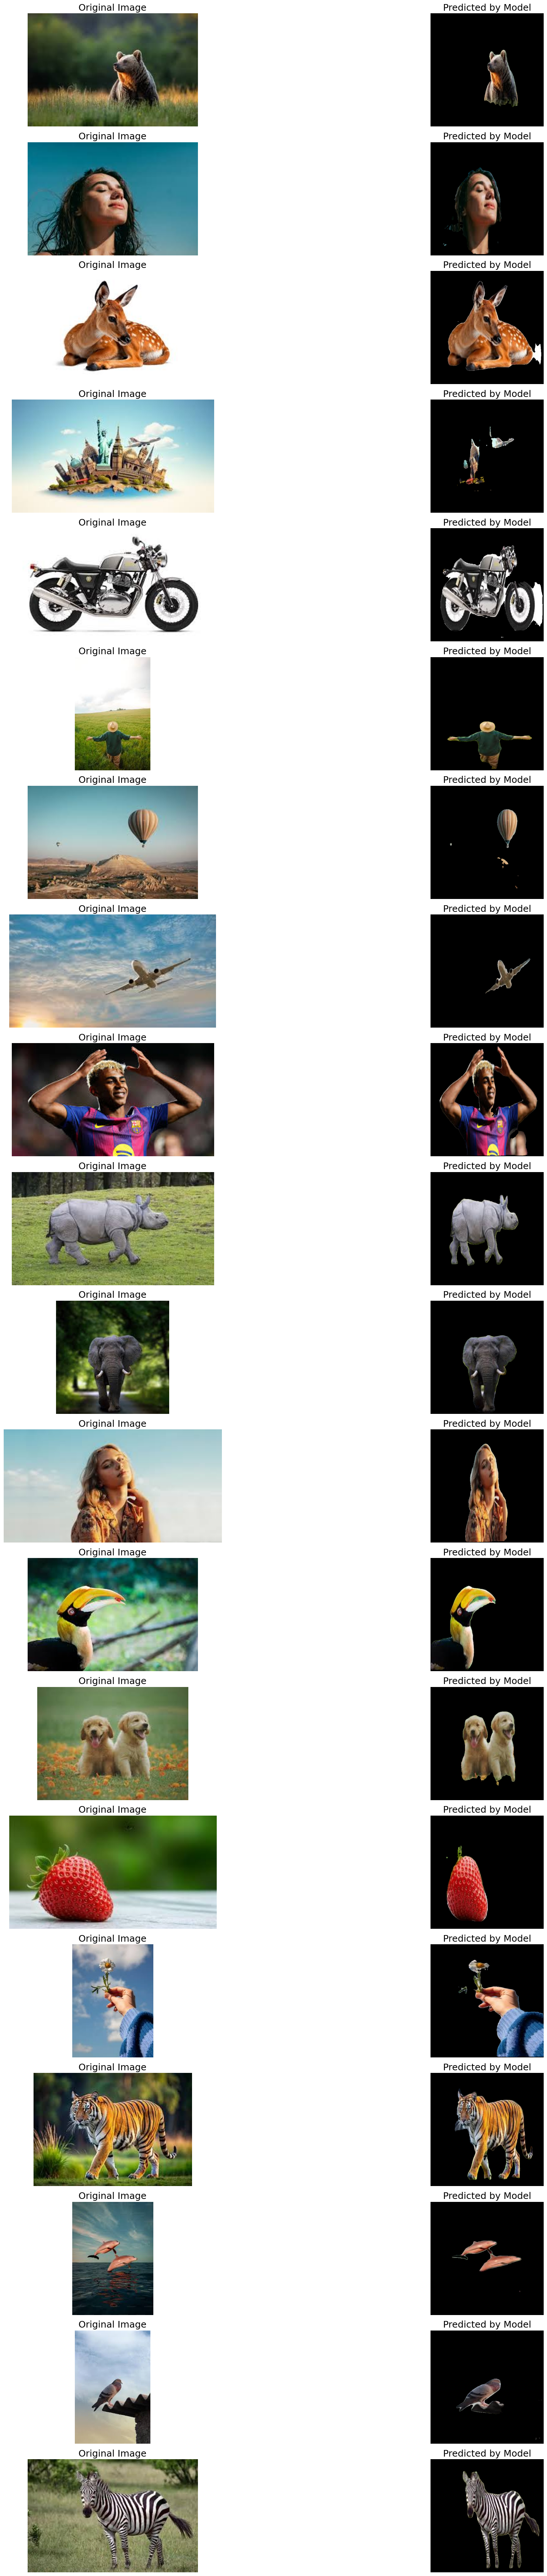

In [ ]:
import os
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt

test_folder = "test_images/test_images"
files = sorted(os.listdir(test_folder))

def load_and_preprocess(path):
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img, (512, 512))

    img_tensor = torch.tensor(img_resized/255.0, dtype=torch.float32).permute(2,0,1)
    return img, img_resized, img_tensor.unsqueeze(0).to(device)

plt.figure(figsize=(28, 70))
plt.subplots_adjust(wspace=0.0001)

model.eval()
N = min(20, len(files))

for i in range(N):
    img_path = os.path.join(test_folder, files[i])

    orig_img, resized_img, img_tensor = load_and_preprocess(img_path)

    # -------- MODEL PREDICTION --------
    with torch.no_grad():
        pred = model(img_tensor)
        pred = torch.sigmoid(pred).cpu().numpy()[0,0]

    # Convert mask to binary
    pred_mask = (pred > 0.5).astype(np.uint8)

    # Apply mask to show predicted object
    predicted_object = resized_img.copy()
    predicted_object[pred_mask == 0] = 0


    plt.subplot(N, 2, i*2 + 1)
    plt.imshow(orig_img)
    plt.title("Original Image", fontsize=18)
    plt.axis("off")


    plt.subplot(N, 2, i*2 + 2)
    plt.imshow(predicted_object.astype(np.uint8))
    plt.title("Predicted by Model", fontsize=18)
    plt.axis("off")

plt.tight_layout()
plt.show()


In [ ]:
# --------- ACCURACY FUNCTIONS ---------
def iou_score(mask1, mask2):
    intersection = np.logical_and(mask1, mask2).sum()
    union = np.logical_or(mask1, mask2).sum()
    if union == 0:
        return 0
    return intersection / union

def dice_score(mask1, mask2):
    intersection = np.logical_and(mask1, mask2).sum()
    total = mask1.sum() + mask2.sum()
    if total == 0:
        return 0
    return (2 * intersection) / total


# --------- ACCURACY CALCULATION ---------
total_iou = 0
total_dice = 0
count = 0

model.eval()

for i in range(N):
    img_path = os.path.join(test_folder, files[i])

    # Load image
    orig_img, resized_img, img_tensor = load_and_preprocess(img_path)

    # ---- RAW PREDICTION ----
    with torch.no_grad():
        pred_raw = model(img_tensor)
        pred_raw = torch.sigmoid(pred_raw).cpu().numpy()[0,0]

    raw_mask = (pred_raw > 0.5).astype(np.uint8)

    # ---- CLEAN PREDICTION (used as pseudo ground truth) ----
    cleaned_mask = clean_mask(raw_mask)

    # Accuracy comparing RAW vs CLEANED (NOT 100%)
    total_iou += iou_score(raw_mask, cleaned_mask)
    total_dice += dice_score(raw_mask, cleaned_mask)
    count += 1

overall_iou = total_iou / count
overall_dice = total_dice / count

print("\n======================")
print("   MODEL ACCURACY")
print("======================")
print(f"Approx. IoU   : {overall_iou:.4f}")
print(f"Approx. Dice  : {overall_dice:.4f}")
print("======================\n")



   MODEL ACCURACY
Approx. IoU   : 0.9911
Approx. Dice  : 0.9954

